# Exercise 1: Applying the Machine Learning Pipeline

This notebook walks through a compact end-to-end machine learning workflow using a built-in `scikit-learn` dataset.

**Goal:** Predict whether a breast tumor is malignant or benign using diagnostic measurements.

This is not intended to be a medically complete model. It is a teaching exercise designed to show how the machine learning pipeline fits together from problem definition through monitoring considerations.


## 1. Problem definition

We will build a supervised classification model.

- **Business / analytic question:** Can we predict tumor class from diagnostic measurements?
- **Prediction target:** `target`, where `0 = malignant` and `1 = benign`
- **Modeling task:** Binary classification
- **Success criteria:** Strong performance on the minority class, not just high overall accuracy

Because this is a health-related classification problem, recall and false negatives matter. A model that misses too many malignant cases would be unacceptable, even if its overall accuracy looks high.


In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Data and modeling tools
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Visualization
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 1955


## 2. Data collection and preprocessing

The dataset is built into `scikit-learn`, so no external download is required.

We will load the data, convert it to a DataFrame, inspect the target classes, and check for missing values.


In [2]:
# Load dataset
data = load_breast_cancer()

# Create feature matrix and target vector
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Combine for quick inspection
df = X.copy()
df["target"] = y

print("Dataset shape:", df.shape)
print("\nTarget names:", dict(enumerate(data.target_names)))
print("\nClass distribution:")
print(y.value_counts().rename(index=dict(enumerate(data.target_names))))

df.head()


Dataset shape: (569, 31)

Target names: {0: np.str_('malignant'), 1: np.str_('benign')}

Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Check for missing values
missing_values = df.isna().sum().sum()

print("Total missing values:", missing_values)
print("\nFeature summary:")
X.describe().T.head(10)


Total missing values: 0

Feature summary:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## 3. Feature engineering and selection

For this short exercise, we will keep the original numeric features. However, we still need one important preprocessing step: **standardization**.

Logistic regression is sensitive to feature scale. Standardizing the variables helps the model treat features more comparably during training.

We will use a `Pipeline` so that scaling is learned only from the training data and then applied to the test data. This helps prevent data leakage.


In [4]:
# Train/test split
# stratify=y preserves the class balance in both training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTraining class balance:")
print(y_train.value_counts(normalize=True).rename(index=dict(enumerate(data.target_names))))

print("\nTest class balance:")
print(y_test.value_counts(normalize=True).rename(index=dict(enumerate(data.target_names))))


Training shape: (426, 30)
Test shape: (143, 30)

Training class balance:
target
benign       0.626761
malignant    0.373239
Name: proportion, dtype: float64

Test class balance:
target
benign       0.629371
malignant    0.370629
Name: proportion, dtype: float64


## 4. Model training

We will train a logistic regression classifier.

Logistic regression is a useful baseline model because it is relatively interpretable, fast, and often performs well on structured classification problems.


In [5]:
# Build the modeling pipeline
model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Train the model
model.fit(X_train, y_train)

print("Model training complete.")


Model training complete.


## 5. Validation and evaluation

Now we evaluate the model on data it did not see during training.

We will look at:

- Accuracy
- Precision, recall, and F1-score
- Confusion matrix
- ROC curve

Accuracy alone can be misleading, especially when one class is more important or less common than another.


In [6]:
# Generate predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluate
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=data.target_names, digits=4))


Accuracy: 0.9860

Classification report:
              precision    recall  f1-score   support

   malignant     0.9811    0.9811    0.9811        53
      benign     0.9889    0.9889    0.9889        90

    accuracy                         0.9860       143
   macro avg     0.9850    0.9850    0.9850       143
weighted avg     0.9860    0.9860    0.9860       143



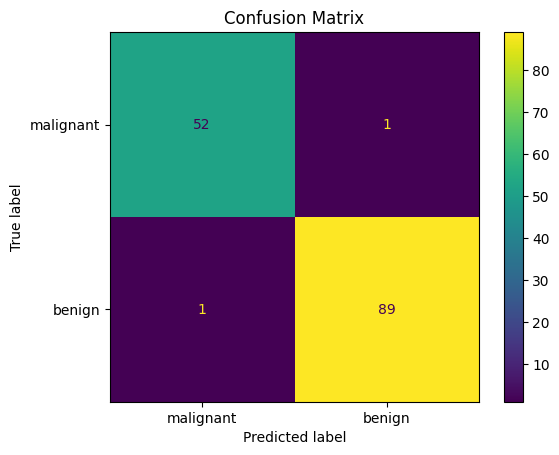

In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()


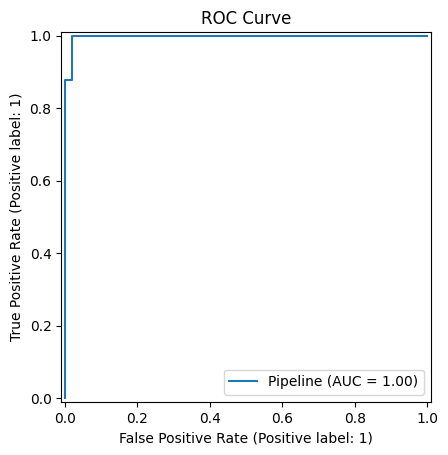

In [8]:
# ROC curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()


## 6. Deployment into real-world systems

In a real deployment, the model would need to be embedded into a larger decision system.

That system would need to define:

- Where the input data comes from
- When predictions are generated
- Who receives the prediction
- What action is taken based on the prediction
- What safeguards or human review steps are required

For this exercise, we will simulate a single new observation being passed into the trained pipeline.


In [9]:
# Simulate one new case using a row from the test set
new_case = X_test.iloc[[0]]

predicted_class = model.predict(new_case)[0]
predicted_probability = model.predict_proba(new_case)[0, predicted_class]

print("Predicted class:", data.target_names[predicted_class])
print(f"Model confidence for predicted class: {predicted_probability:.4f}")

new_case


Predicted class: benign
Model confidence for predicted class: 0.9690


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
519,12.75,16.7,82.51,493.8,0.1125,0.1117,0.0388,0.02995,0.212,0.06623,...,14.45,21.74,93.63,624.1,0.1475,0.1979,0.1423,0.08045,0.3071,0.08557


## 7. Monitoring and updating as data evolves

A deployed model is rarely finished (forever). Over time, data patterns can shift.

Monitoring should include:

- Changes in incoming feature distributions
- Changes in class balance
- Changes in prediction confidence
- Changes in error rates
- Feedback from users or domain experts

Just for fun...below, we compare the training data to a simulated “new batch” of incoming data.


In [10]:
# Simulate a new incoming batch from the test data
new_batch = X_test.sample(20, random_state=RANDOM_STATE)

# Compare feature means between training data and new batch
monitoring_table = pd.DataFrame({
    "training_mean": X_train.mean(),
    "new_batch_mean": new_batch.mean()
})

monitoring_table["absolute_difference"] = (
    monitoring_table["new_batch_mean"] - monitoring_table["training_mean"]
).abs()

monitoring_table.sort_values("absolute_difference", ascending=False).head(10)


,training_mean,new_batch_mean,absolute_difference
worst area,872.524413,910.515000,37.990587
mean area,649.627230,682.305000,32.677770
area error,39.171439,61.507500,22.336061
worst perimeter,106.803732,105.195500,1.608232
worst texture,25.708263,24.813500,0.894763
perimeter error,2.825113,3.329525,0.504412
mean texture,19.295047,18.896500,0.398547
worst radius,16.202542,15.958000,0.244542
mean perimeter,91.592911,91.726000,0.133089
texture error,1.213723,1.319105,0.105382


## Wrap-up

This notebook applied the full machine learning pipeline:

1. Defined the prediction problem
2. Loaded and inspected the data
3. Prepared features using a preprocessing pipeline
4. Trained a baseline model
5. Evaluated performance on held-out data
6. Simulated deployment on a new case
7. Discussed monitoring and model updating

The main point--  machine learning is not just model fitting. The model is one part of a larger decision and data system.
